# Assignment 1 - Unit 2: Linear Regression

**Name:** Adarsh Pandey
**Roll No.:** 14
**Subject:** Machine Learning
**Department:** Computer Science, Gujarat University - MSc AIML-2

## Question 1 - Airfare vs Distance (12 Cities)

Slope     (a1): 0.1174 $/mile
Intercept (a0): 83.2674 $
SSE: 14308.8378


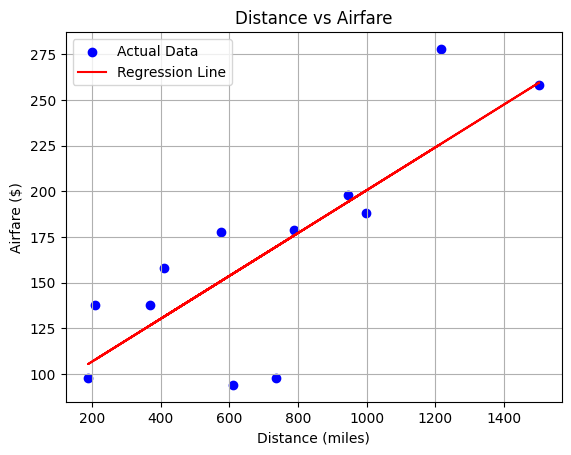

In [1]:
import numpy as np
import matplotlib.pyplot as plt

distance_x = np.array([576, 370, 612, 1216, 409, 1502, 946, 998, 189, 787, 210, 737])
airfare_y  = np.array([178, 138,  94,  278, 158,  258, 198, 188,  98, 179, 138,  98])
n = len(distance_x)

sum_x  = np.sum(distance_x)
sum_y  = np.sum(airfare_y)
sum_xy = np.sum(distance_x * airfare_y)
sum_x2 = np.sum(distance_x ** 2)

a1_slope     = ((n * sum_xy) - (sum_x * sum_y)) / ((n * sum_x2) - (sum_x ** 2))
a0_intercept = (sum_y - (a1_slope * sum_x)) / n

print(f"Slope     (a1): {a1_slope:.4f} $/mile")
print(f"Intercept (a0): {a0_intercept:.4f} $")

predicted_y = a0_intercept + (a1_slope * distance_x)
error = airfare_y - predicted_y
sse   = np.sum(error ** 2)
print(f"SSE: {sse:.4f}")

plt.scatter(distance_x, airfare_y, color='blue', label='Actual Data')
plt.plot(distance_x, predicted_y, color='red', label='Regression Line')
plt.title("Distance vs Airfare")
plt.xlabel("Distance (miles)"); plt.ylabel("Airfare ($)")
plt.legend(); plt.grid(True); plt.show()

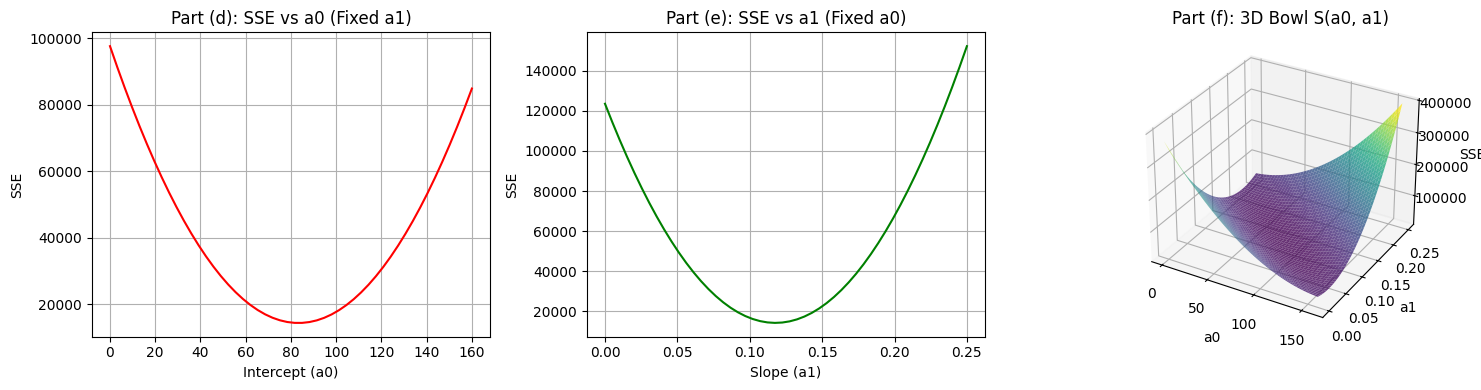

In [2]:
import numpy as np
import matplotlib.pyplot as plt

distance_x = np.array([576, 370, 612, 1216, 409, 1502, 946, 998, 189, 787, 210, 737])
airfare_y  = np.array([178, 138,  94,  278, 158,  258, 198, 188,  98, 179, 138,  98])

best_a1 = 0.1173
best_a0 = 82.9526

def calculate_sse(a0, a1):
    return np.sum((airfare_y - (a0 + a1 * distance_x)) ** 2)

a0_values = np.linspace(0, 160, 50)
a1_values = np.linspace(0.0, 0.25, 50)
sse_a0 = [calculate_sse(a0, best_a1) for a0 in a0_values]
sse_a1 = [calculate_sse(best_a0, a1) for a1 in a1_values]

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(a0_values, sse_a0, color='red')
plt.title("Part (d): SSE vs a0 (Fixed a1)")
plt.xlabel("Intercept (a0)"); plt.ylabel("SSE"); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(a1_values, sse_a1, color='green')
plt.title("Part (e): SSE vs a1 (Fixed a0)")
plt.xlabel("Slope (a1)"); plt.ylabel("SSE"); plt.grid(True)

ax = plt.subplot(1, 3, 3, projection='3d')
A0, A1 = np.meshgrid(a0_values, a1_values)
SSE_3D = np.zeros_like(A0)
for i in range(A0.shape[0]):
    for j in range(A0.shape[1]):
        SSE_3D[i, j] = calculate_sse(A0[i, j], A1[i, j])
ax.plot_surface(A0, A1, SSE_3D, cmap='viridis', alpha=0.8)
ax.set_title("Part (f): 3D Bowl S(a0, a1)")
ax.set_xlabel("a0"); ax.set_ylabel("a1"); ax.set_zlabel("SSE")

plt.tight_layout(); plt.show()

In [3]:
import numpy as np
import pandas as pd

distance_x = np.array([576, 370, 612, 1216, 409, 1502, 946, 998, 189, 787, 210, 737])
airfare_y  = np.array([178, 138,  94,  278, 158,  258, 198, 188,  98, 179, 138,  98])
n = len(distance_x)

x_mean   = np.mean(distance_x)
x_std    = np.std(distance_x)
x_scaled = (distance_x - x_mean) / x_std

a0, a1   = 0.0, 0.0
alpha    = 0.1
iterations = 50
history  = []

for i in range(iterations):
    y_pred = a0 + a1 * x_scaled
    error  = y_pred - airfare_y
    sse    = np.sum(error ** 2)
    if i < 5 or i % 10 == 0 or i == iterations - 1:
        history.append({"Iteration": i, "a0": round(a0, 4), "a1": round(a1, 4), "SSE": round(sse, 4)})
    grad_a0 = (1/n) * np.sum(error)
    grad_a1 = (1/n) * np.sum(error * x_scaled)
    a0 -= alpha * grad_a0
    a1 -= alpha * grad_a1

print(pd.DataFrame(history).to_string(index=False))

a1_final = a1 / x_std
a0_final = a0 - (a1 * x_mean / x_std)
print(f"\nSlope (a1): {a1_final:.4f}")
print(f"Intercept (a0): {a0_final:.4f}")

 Iteration       a0      a1         SSE
         0   0.0000  0.0000 373217.0000
         1  16.6917  4.5253 305024.4492
         2  31.7142  8.5981 249788.4830
         3  45.2344 12.2636 205047.3504
         4  57.4026 15.5625 168807.0330
        10 108.7164 29.4743  57943.6915
        20 146.6235 39.7513  19613.8173
        30 159.8409 43.3347  14953.7994
        40 164.4495 44.5842  14387.2501
        49 165.9608 44.9939  14320.6070

Slope (a1): 0.1168
Intercept (a0): 82.8382


In [4]:
import numpy as np

distance_x = np.array([576, 370, 612, 1216, 409, 1502, 946, 998, 189, 787, 210, 737])
airfare_y  = np.array([178, 138,  94,  278, 158,  258, 198, 188,  98, 179, 138,  98])
n = len(distance_x)

X_matrix = np.column_stack((np.ones(n), distance_x))
b = np.dot(np.dot(np.linalg.inv(np.dot(X_matrix.T, X_matrix)), X_matrix.T), airfare_y)

a0_matrix = b[0]
a1_matrix = b[1]

print(f"Intercept (a0): {a0_matrix:.4f}")
print(f"Slope     (a1): {a1_matrix:.4f}")

Intercept (a0): 83.2674
Slope     (a1): 0.1174


In [5]:
from sklearn.linear_model import LinearRegression
import numpy as np

distance_x = np.array([576, 370, 612, 1216, 409, 1502, 946, 998, 189, 787, 210, 737])
airfare_y  = np.array([178, 138,  94,  278, 158,  258, 198, 188,  98, 179, 138,  98])

model = LinearRegression()
model.fit(distance_x.reshape(-1, 1), airfare_y)

print(f"Intercept (a0): {model.intercept_:.4f}")
print(f"Slope     (a1): {model.coef_[0]:.4f}")

Intercept (a0): 83.2674
Slope     (a1): 0.1174


In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

distance_x = np.array([576, 370, 612, 1216, 409, 1502, 946, 998, 189, 787, 210, 737])
airfare_y  = np.array([178, 138,  94,  278, 158,  258, 198, 188,  98, 179, 138,  98])
n = len(distance_x)

X_matrix = np.column_stack((np.ones(n), distance_x))
b = np.dot(np.dot(np.linalg.inv(np.dot(X_matrix.T, X_matrix)), X_matrix.T), airfare_y)
y_pred = b[0] + b[1] * distance_x
error  = airfare_y - y_pred

mae_hc  = np.mean(np.abs(error))
mse_hc  = np.mean(error ** 2)
rmse_hc = np.sqrt(mse_hc)
r2_hc   = 1 - (np.sum(error**2) / np.sum((airfare_y - np.mean(airfare_y))**2))

model = LinearRegression().fit(distance_x.reshape(-1, 1), airfare_y)
y_sk  = model.predict(distance_x.reshape(-1, 1))

print(f"MAE  -> Hardcoded: {mae_hc:.4f}  |  Sklearn: {mean_absolute_error(airfare_y, y_sk):.4f}")
print(f"MSE  -> Hardcoded: {mse_hc:.4f}  |  Sklearn: {mean_squared_error(airfare_y, y_sk):.4f}")
print(f"RMSE -> Hardcoded: {rmse_hc:.4f}  |  Sklearn: {np.sqrt(mean_squared_error(airfare_y, y_sk)):.4f}")
print(f"R²   -> Hardcoded: {r2_hc:.4f}  |  Sklearn: {r2_score(airfare_y, y_sk):.4f}")

MAE  -> Hardcoded: 25.7162  |  Sklearn: 25.7162
MSE  -> Hardcoded: 1192.4031  |  Sklearn: 1192.4031
RMSE -> Hardcoded: 34.5312  |  Sklearn: 34.5312
R²   -> Hardcoded: 0.6320  |  Sklearn: 0.6320


## Question 2 - Relative Humidity vs Solvent Evaporation (25 data points)

Slope     (a1): -0.0801  [%wt per %RH]
Intercept (a0): 13.6389  [%wt]
SSE: 18.0607


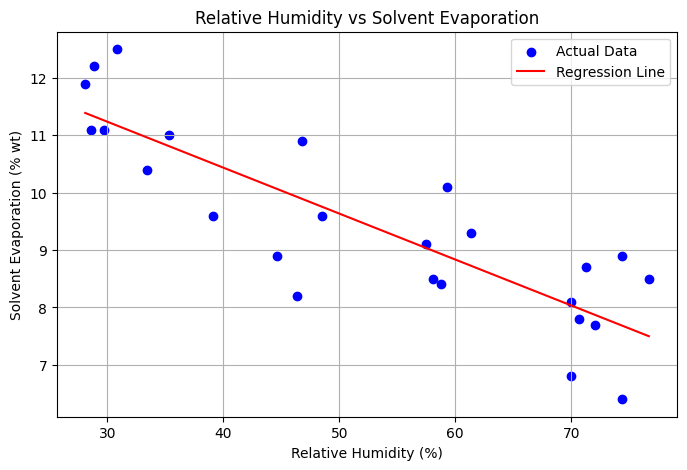

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([35.3,29.7,30.8,58.8,61.4,71.3,74.4,76.7,70.7,57.5,46.4,28.9,28.1,39.1,46.8,48.5,59.3,70.0,70.0,74.4,72.1,58.1,44.6,33.4,28.6])
y = np.array([11.0,11.1,12.5,8.4,9.3,8.7,6.4,8.5,7.8,9.1,8.2,12.2,11.9,9.6,10.9,9.6,10.1,8.1,6.8,8.9,7.7,8.5,8.9,10.4,11.1])
n = len(x)

sum_x = np.sum(x); sum_y = np.sum(y)
sum_xy = np.sum(x * y); sum_x2 = np.sum(x ** 2)

a1 = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
a0 = (sum_y - a1 * sum_x) / n

print(f"Slope     (a1): {a1:.4f}  [%wt per %RH]")
print(f"Intercept (a0): {a0:.4f}  [%wt]")

y_pred = a0 + a1 * x
sse = np.sum((y - y_pred) ** 2)
print(f"SSE: {sse:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
x_line = np.linspace(min(x), max(x), 100)
plt.plot(x_line, a0 + a1 * x_line, color='red', label='Regression Line')
plt.title("Relative Humidity vs Solvent Evaporation")
plt.xlabel("Relative Humidity (%)"); plt.ylabel("Solvent Evaporation (% wt)")
plt.legend(); plt.grid(True); plt.show()

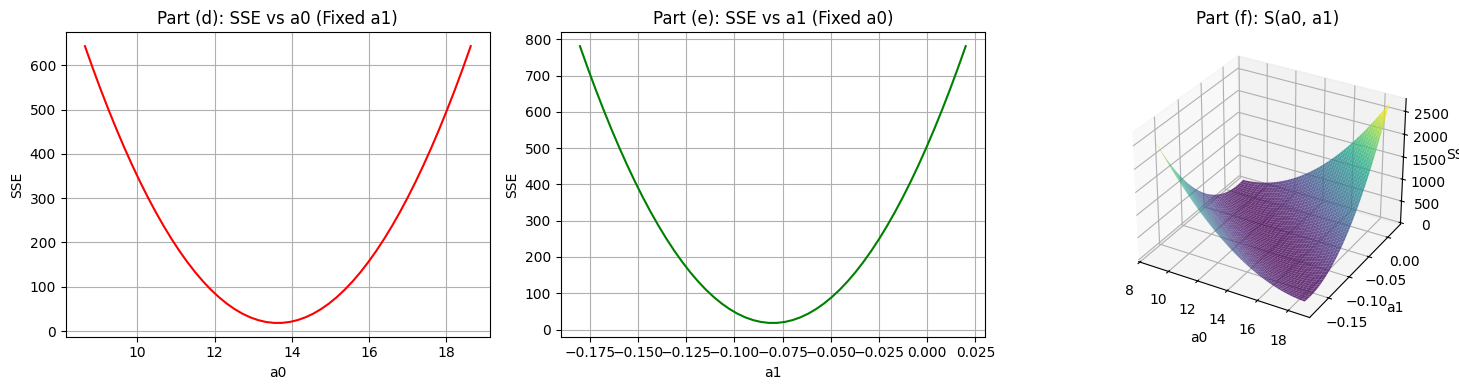

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([35.3,29.7,30.8,58.8,61.4,71.3,74.4,76.7,70.7,57.5,46.4,28.9,28.1,39.1,46.8,48.5,59.3,70.0,70.0,74.4,72.1,58.1,44.6,33.4,28.6])
y = np.array([11.0,11.1,12.5,8.4,9.3,8.7,6.4,8.5,7.8,9.1,8.2,12.2,11.9,9.6,10.9,9.6,10.1,8.1,6.8,8.9,7.7,8.5,8.9,10.4,11.1])
n = len(x)

sum_x = np.sum(x); sum_y = np.sum(y)
sum_xy = np.sum(x * y); sum_x2 = np.sum(x ** 2)
ba1 = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
ba0 = (sum_y - ba1 * sum_x) / n

def sse(a0, a1): return np.sum((y - (a0 + a1 * x)) ** 2)

a0_vals = np.linspace(ba0 - 5, ba0 + 5, 50)
a1_vals = np.linspace(ba1 - 0.1, ba1 + 0.1, 50)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(a0_vals, [sse(v, ba1) for v in a0_vals], color='red')
plt.title("Part (d): SSE vs a0 (Fixed a1)")
plt.xlabel("a0"); plt.ylabel("SSE"); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(a1_vals, [sse(ba0, v) for v in a1_vals], color='green')
plt.title("Part (e): SSE vs a1 (Fixed a0)")
plt.xlabel("a1"); plt.ylabel("SSE"); plt.grid(True)

ax = plt.subplot(1, 3, 3, projection='3d')
A0, A1 = np.meshgrid(a0_vals, a1_vals)
SSE3D  = np.vectorize(sse)(A0, A1)
ax.plot_surface(A0, A1, SSE3D, cmap='viridis', alpha=0.8)
ax.set_title("Part (f): S(a0, a1)")
ax.set_xlabel("a0"); ax.set_ylabel("a1"); ax.set_zlabel("SSE")

plt.tight_layout(); plt.show()

In [9]:
import numpy as np
import pandas as pd

x = np.array([35.3,29.7,30.8,58.8,61.4,71.3,74.4,76.7,70.7,57.5,46.4,28.9,28.1,39.1,46.8,48.5,59.3,70.0,70.0,74.4,72.1,58.1,44.6,33.4,28.6])
y = np.array([11.0,11.1,12.5,8.4,9.3,8.7,6.4,8.5,7.8,9.1,8.2,12.2,11.9,9.6,10.9,9.6,10.1,8.1,6.8,8.9,7.7,8.5,8.9,10.4,11.1])
n = len(x)

x_m, x_s = np.mean(x), np.std(x)
xs = (x - x_m) / x_s

a0, a1, alpha, iters = 0.0, 0.0, 0.1, 50
history = []

for i in range(iters):
    err = (a0 + a1 * xs) - y
    sse = np.sum(err ** 2)
    if i < 5 or i % 10 == 0 or i == iters - 1:
        history.append({"Iteration": i, "a0": round(a0, 4), "a1": round(a1, 4), "SSE": round(sse, 4)})
    a0 -= alpha * (1/n) * np.sum(err)
    a1 -= alpha * (1/n) * np.sum(err * xs)

print(pd.DataFrame(history).to_string(index=False))
a1_f = a1 / x_s
a0_f = a0 - a1 * x_m / x_s
print(f"\nSlope (a1): {a1_f:.4f}")
print(f"Intercept (a0): {a0_f:.4f}")

 Iteration     a0      a1       SSE
         0 0.0000  0.0000 2286.0700
         1 0.9428 -0.1354 1855.1482
         2 1.7913 -0.2573 1506.1016
         3 2.5550 -0.3669 1223.3738
         4 3.2423 -0.4656  994.3644
        10 6.1407 -0.8819  293.7977
        20 8.2818 -1.1893   51.5839
        30 9.0283 -1.2966   22.1364
        40 9.2886 -1.3339   18.5562
        49 9.3740 -1.3462   18.1351

Slope (a1): -0.0796
Intercept (a0): 13.5686


In [10]:
import numpy as np

x = np.array([35.3,29.7,30.8,58.8,61.4,71.3,74.4,76.7,70.7,57.5,46.4,28.9,28.1,39.1,46.8,48.5,59.3,70.0,70.0,74.4,72.1,58.1,44.6,33.4,28.6])
y = np.array([11.0,11.1,12.5,8.4,9.3,8.7,6.4,8.5,7.8,9.1,8.2,12.2,11.9,9.6,10.9,9.6,10.1,8.1,6.8,8.9,7.7,8.5,8.9,10.4,11.1])
n = len(x)

X = np.column_stack((np.ones(n), x))
b = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"Intercept (a0): {b[0]:.4f}")
print(f"Slope     (a1): {b[1]:.4f}")

Intercept (a0): 13.6389
Slope     (a1): -0.0801


In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np

x = np.array([35.3,29.7,30.8,58.8,61.4,71.3,74.4,76.7,70.7,57.5,46.4,28.9,28.1,39.1,46.8,48.5,59.3,70.0,70.0,74.4,72.1,58.1,44.6,33.4,28.6])
y = np.array([11.0,11.1,12.5,8.4,9.3,8.7,6.4,8.5,7.8,9.1,8.2,12.2,11.9,9.6,10.9,9.6,10.1,8.1,6.8,8.9,7.7,8.5,8.9,10.4,11.1])

model = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"Intercept (a0): {model.intercept_:.4f}")
print(f"Slope     (a1): {model.coef_[0]:.4f}")

Intercept (a0): 13.6389
Slope     (a1): -0.0801


In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x = np.array([35.3,29.7,30.8,58.8,61.4,71.3,74.4,76.7,70.7,57.5,46.4,28.9,28.1,39.1,46.8,48.5,59.3,70.0,70.0,74.4,72.1,58.1,44.6,33.4,28.6])
y = np.array([11.0,11.1,12.5,8.4,9.3,8.7,6.4,8.5,7.8,9.1,8.2,12.2,11.9,9.6,10.9,9.6,10.1,8.1,6.8,8.9,7.7,8.5,8.9,10.4,11.1])
n = len(x)

X = np.column_stack((np.ones(n), x))
b = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = b[0] + b[1] * x
err = y - y_pred

mae_hc  = np.mean(np.abs(err))
mse_hc  = np.mean(err ** 2)
rmse_hc = np.sqrt(mse_hc)
r2_hc   = 1 - np.sum(err**2) / np.sum((y - np.mean(y))**2)

model = LinearRegression().fit(x.reshape(-1, 1), y)
y_sk  = model.predict(x.reshape(-1, 1))

print(f"MAE  -> Hardcoded: {mae_hc:.4f}  |  Sklearn: {mean_absolute_error(y, y_sk):.4f}")
print(f"MSE  -> Hardcoded: {mse_hc:.4f}  |  Sklearn: {mean_squared_error(y, y_sk):.4f}")
print(f"RMSE -> Hardcoded: {rmse_hc:.4f}  |  Sklearn: {np.sqrt(mean_squared_error(y, y_sk)):.4f}")
print(f"R²   -> Hardcoded: {r2_hc:.4f}  |  Sklearn: {r2_score(y, y_sk):.4f}")

MAE  -> Hardcoded: 0.7050  |  Sklearn: 0.7050
MSE  -> Hardcoded: 0.7224  |  Sklearn: 0.7224
RMSE -> Hardcoded: 0.8500  |  Sklearn: 0.8500
R²   -> Hardcoded: 0.7173  |  Sklearn: 0.7173


## Question 3 - Crack Rating (Multiple Linear Regression: x1=Permeability, x2=Fracture Energy)

Intercept (a0): 0.8047
Slope     (a1): 0.2452  [per unit Permeability]
Slope     (a2): 0.2637  [per unit Fracture Energy]
SSE: 6.6034


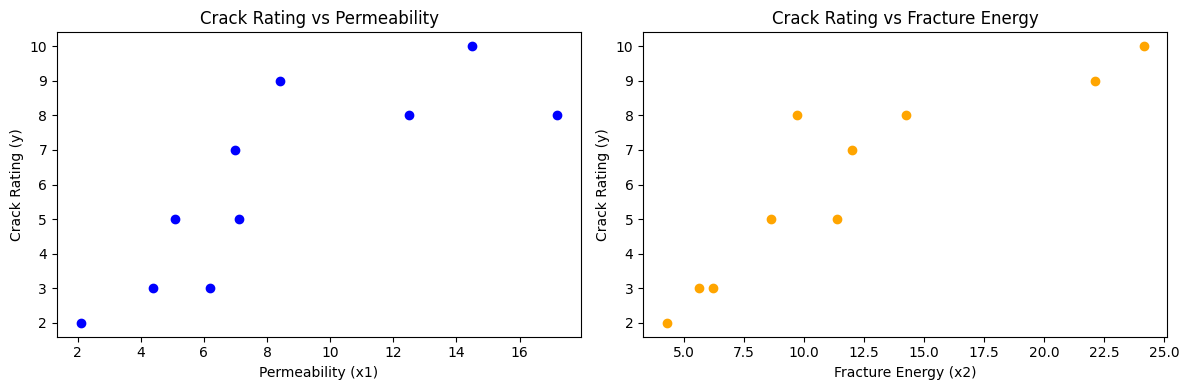

In [13]:
import numpy as np
import matplotlib.pyplot as plt

y  = np.array([2, 9, 5, 10, 3, 3, 8, 7, 8, 5], dtype=float)
x1 = np.array([2.1, 8.4, 5.1, 14.5, 4.4, 6.2, 12.5, 7.0, 17.2, 7.1])
x2 = np.array([4.31, 22.11, 11.40, 24.15, 6.21, 5.65, 9.71, 12.00, 14.25, 8.63])
n = len(y)

X = np.column_stack((np.ones(n), x1, x2))
b = np.linalg.inv(X.T @ X) @ X.T @ y
a0, a1, a2 = b

print(f"Intercept (a0): {a0:.4f}")
print(f"Slope     (a1): {a1:.4f}  [per unit Permeability]")
print(f"Slope     (a2): {a2:.4f}  [per unit Fracture Energy]")

y_pred = a0 + a1 * x1 + a2 * x2
sse = np.sum((y - y_pred) ** 2)
print(f"SSE: {sse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x1, y, color='blue')
axes[0].set_title("Crack Rating vs Permeability")
axes[0].set_xlabel("Permeability (x1)"); axes[0].set_ylabel("Crack Rating (y)")
axes[1].scatter(x2, y, color='orange')
axes[1].set_title("Crack Rating vs Fracture Energy")
axes[1].set_xlabel("Fracture Energy (x2)"); axes[1].set_ylabel("Crack Rating (y)")
plt.tight_layout(); plt.show()

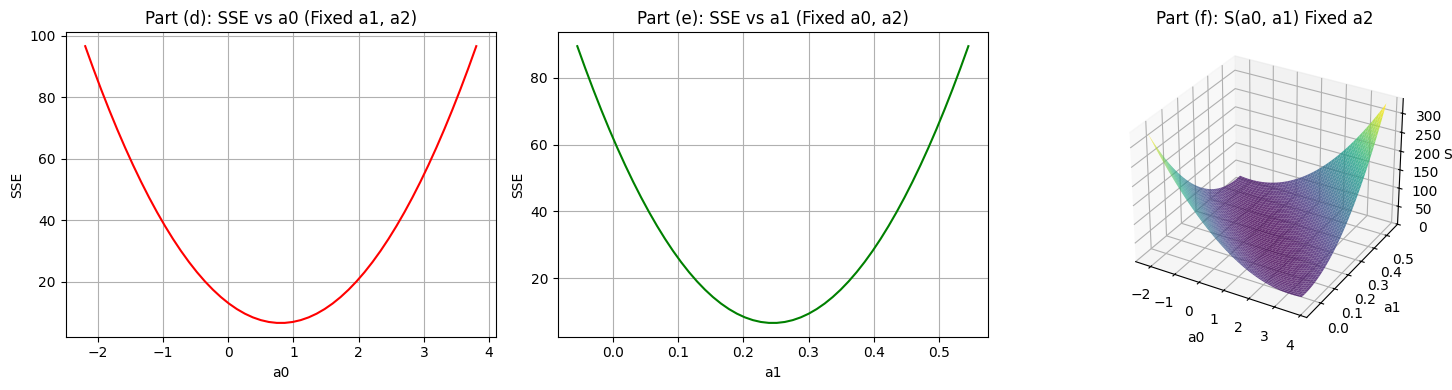

In [14]:
import numpy as np
import matplotlib.pyplot as plt

y  = np.array([2, 9, 5, 10, 3, 3, 8, 7, 8, 5], dtype=float)
x1 = np.array([2.1, 8.4, 5.1, 14.5, 4.4, 6.2, 12.5, 7.0, 17.2, 7.1])
x2 = np.array([4.31, 22.11, 11.40, 24.15, 6.21, 5.65, 9.71, 12.00, 14.25, 8.63])
n = len(y)

X = np.column_stack((np.ones(n), x1, x2))
b = np.linalg.inv(X.T @ X) @ X.T @ y
a0, a1, a2 = b

def sse(b0, b1, b2): return np.sum((y - (b0 + b1 * x1 + b2 * x2)) ** 2)

a0_vals = np.linspace(a0 - 3, a0 + 3, 50)
a1_vals = np.linspace(a1 - 0.3, a1 + 0.3, 50)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(a0_vals, [sse(v, a1, a2) for v in a0_vals], color='red')
plt.title("Part (d): SSE vs a0 (Fixed a1, a2)")
plt.xlabel("a0"); plt.ylabel("SSE"); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(a1_vals, [sse(a0, v, a2) for v in a1_vals], color='green')
plt.title("Part (e): SSE vs a1 (Fixed a0, a2)")
plt.xlabel("a1"); plt.ylabel("SSE"); plt.grid(True)

ax = plt.subplot(1, 3, 3, projection='3d')
A0, A1 = np.meshgrid(a0_vals, a1_vals)
SSE3D  = np.vectorize(lambda b0, b1: sse(b0, b1, a2))(A0, A1)
ax.plot_surface(A0, A1, SSE3D, cmap='viridis', alpha=0.8)
ax.set_title("Part (f): S(a0, a1) Fixed a2")
ax.set_xlabel("a0"); ax.set_ylabel("a1"); ax.set_zlabel("SSE")

plt.tight_layout(); plt.show()

In [15]:
import numpy as np
import pandas as pd

y  = np.array([2, 9, 5, 10, 3, 3, 8, 7, 8, 5], dtype=float)
x1 = np.array([2.1, 8.4, 5.1, 14.5, 4.4, 6.2, 12.5, 7.0, 17.2, 7.1])
x2 = np.array([4.31, 22.11, 11.40, 24.15, 6.21, 5.65, 9.71, 12.00, 14.25, 8.63])
n = len(y)

x1_m, x1_s = np.mean(x1), np.std(x1)
x2_m, x2_s = np.mean(x2), np.std(x2)
x1s = (x1 - x1_m) / x1_s
x2s = (x2 - x2_m) / x2_s

a0, a1, a2, alpha, iters = 0.0, 0.0, 0.0, 0.1, 100
history = []

for i in range(iters):
    err = (a0 + a1 * x1s + a2 * x2s) - y
    sse = np.sum(err ** 2)
    if i < 5 or i % 20 == 0 or i == iters - 1:
        history.append({"Iter": i, "a0": round(a0, 4), "a1": round(a1, 4), "a2": round(a2, 4), "SSE": round(sse, 4)})
    a0 -= alpha * (1/n) * np.sum(err)
    a1 -= alpha * (1/n) * np.sum(err * x1s)
    a2 -= alpha * (1/n) * np.sum(err * x2s)

print(pd.DataFrame(history).to_string(index=False))

a1_f = a1 / x1_s
a2_f = a2 / x2_s
a0_f = a0 - a1 * x1_m / x1_s - a2 * x2_m / x2_s
print(f"\nIntercept (a0): {a0_f:.4f}")
print(f"Slope     (a1): {a1_f:.4f}")
print(f"Slope     (a2): {a2_f:.4f}")

 Iter     a0     a1     a2      SSE
    0 0.0000 0.0000 0.0000 430.0000
    1 0.6000 0.2139 0.2358 342.9572
    2 1.1400 0.3920 0.4350 274.4222
    3 1.6260 0.5401 0.6034 220.2939
    4 2.0634 0.6632 0.7459 177.4237
   20 5.2705 1.2000 1.5087  12.1065
   40 5.9113 1.1706 1.6188   6.7079
   60 5.9892 1.1403 1.6516   6.6099
   80 5.9987 1.1261 1.6659   6.6045
   99 5.9998 1.1198 1.6721   6.6037

Intercept (a0): 0.8045
Slope     (a1): 0.2464
Slope     (a2): 0.2629


In [16]:
import numpy as np

y  = np.array([2, 9, 5, 10, 3, 3, 8, 7, 8, 5], dtype=float)
x1 = np.array([2.1, 8.4, 5.1, 14.5, 4.4, 6.2, 12.5, 7.0, 17.2, 7.1])
x2 = np.array([4.31, 22.11, 11.40, 24.15, 6.21, 5.65, 9.71, 12.00, 14.25, 8.63])
n = len(y)

X = np.column_stack((np.ones(n), x1, x2))
b = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"Intercept (a0): {b[0]:.4f}")
print(f"Slope     (a1): {b[1]:.4f}")
print(f"Slope     (a2): {b[2]:.4f}")

Intercept (a0): 0.8047
Slope     (a1): 0.2452
Slope     (a2): 0.2637


In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np

y  = np.array([2, 9, 5, 10, 3, 3, 8, 7, 8, 5], dtype=float)
x1 = np.array([2.1, 8.4, 5.1, 14.5, 4.4, 6.2, 12.5, 7.0, 17.2, 7.1])
x2 = np.array([4.31, 22.11, 11.40, 24.15, 6.21, 5.65, 9.71, 12.00, 14.25, 8.63])

model = LinearRegression().fit(np.column_stack((x1, x2)), y)
print(f"Intercept (a0): {model.intercept_:.4f}")
print(f"Slope     (a1): {model.coef_[0]:.4f}")
print(f"Slope     (a2): {model.coef_[1]:.4f}")

Intercept (a0): 0.8047
Slope     (a1): 0.2452
Slope     (a2): 0.2637


In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y  = np.array([2, 9, 5, 10, 3, 3, 8, 7, 8, 5], dtype=float)
x1 = np.array([2.1, 8.4, 5.1, 14.5, 4.4, 6.2, 12.5, 7.0, 17.2, 7.1])
x2 = np.array([4.31, 22.11, 11.40, 24.15, 6.21, 5.65, 9.71, 12.00, 14.25, 8.63])
n = len(y)

X = np.column_stack((np.ones(n), x1, x2))
b = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = b[0] + b[1] * x1 + b[2] * x2
err = y - y_pred

mae_hc  = np.mean(np.abs(err))
mse_hc  = np.mean(err ** 2)
rmse_hc = np.sqrt(mse_hc)
r2_hc   = 1 - np.sum(err**2) / np.sum((y - np.mean(y))**2)

model = LinearRegression().fit(np.column_stack((x1, x2)), y)
y_sk  = model.predict(np.column_stack((x1, x2)))

print(f"MAE  -> Hardcoded: {mae_hc:.4f}  |  Sklearn: {mean_absolute_error(y, y_sk):.4f}")
print(f"MSE  -> Hardcoded: {mse_hc:.4f}  |  Sklearn: {mean_squared_error(y, y_sk):.4f}")
print(f"RMSE -> Hardcoded: {rmse_hc:.4f}  |  Sklearn: {np.sqrt(mean_squared_error(y, y_sk)):.4f}")
print(f"R²   -> Hardcoded: {r2_hc:.4f}  |  Sklearn: {r2_score(y, y_sk):.4f}")

MAE  -> Hardcoded: 0.6731  |  Sklearn: 0.6731
MSE  -> Hardcoded: 0.6603  |  Sklearn: 0.6603
RMSE -> Hardcoded: 0.8126  |  Sklearn: 0.8126
R²   -> Hardcoded: 0.9057  |  Sklearn: 0.9057
